<a href="https://colab.research.google.com/github/202618049/Twinkle_202618049_DS605/blob/main/202618049_Lab_03/202618049_Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Lab Assignment - 3**

#**Scikit-learn: Data Preprocessing and Model Performance Evaluation**

##**Objective**
###Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

#**Part A - Data Loading and Preprocessing with Scikit-learn**

In [4]:
import pandas as pd


df = pd.read_csv('hotel_bookings.csv')
display(df)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


###**Task 1 - Load and Understand the Dataset**

● Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

● Check the class distribution of is_canceled and use it as the target y.

● Create X from the remaining usable features. Identify numerical and categorical columns.

In [9]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# 2. Dataset Exploration (Vertical/Transposed View)
print("--- First 5 Rows (Vertical) ---")
print(df.head().T)  # <--- Added .T to flip rows to columns

print("\n--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Summary Statistics (Vertical) ---")
print(df.describe().T)  # <--- Added .T to flip rows to columns

# 3. Check class distribution & set target
print("\n--- Class Distribution of Target (is_canceled) ---")
print(df['is_canceled'].value_counts())

y = df['is_canceled']

# 4. Create feature matrix X
X = df.drop(columns=['is_canceled'])

# 5. Identify numerical and categorical columns (stored silently in memory)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

--- First 5 Rows (Vertical) ---
                                           0             1             2             3             4
hotel                           Resort Hotel  Resort Hotel  Resort Hotel  Resort Hotel  Resort Hotel
is_canceled                                0             0             0             0             0
lead_time                                342           737             7            13            14
arrival_date_year                       2015          2015          2015          2015          2015
arrival_date_month                      July          July          July          July          July
arrival_date_week_number                  27            27            27            27            27
arrival_date_day_of_month                  1             1             1             1             1
stays_in_weekend_nights                    0             0             0             0             0
stays_in_week_nights                       0             0 

###**Task 2 - Missing Values, Leakage, and Outliers**
● Find the missing-value count and percentage for every column.

● Identify columns with very high missingness. Drop them only if justified and state the reason.

● Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

● Check selected numerical features for outliers using boxplots and/or the IQR method.

● Remove only clear/extreme outliers and report how many rows were removed.

--- Missing Values ---
          Missing Count  Percentage (%)
agent             16285       13.677633
country             487        0.409027
children              4        0.003360
Dropped leakage columns: ['reservation_status', 'reservation_status_date']


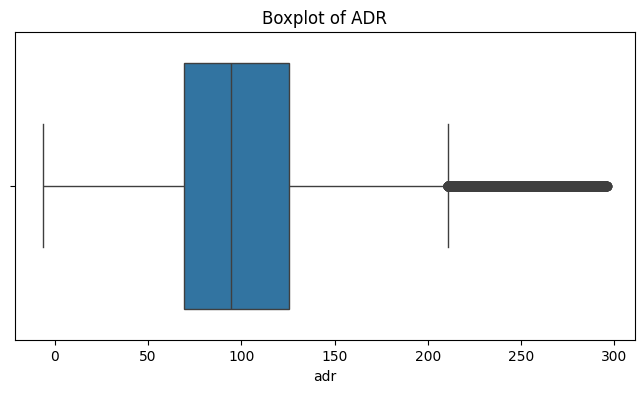


Removed 4 extreme outlier rows.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Find missing values count and percentage
missing_counts = X.isnull().sum()
missing_percent = (missing_counts / len(X)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percent
})

# Show only columns that have missing data
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)
print("--- Missing Values ---")
print(missing_data)

# 2. Drop columns with very high missingness
# The 'company' column is mostly empty (over 94% missing), so it is not useful.
if 'company' in X.columns:
    X = X.drop(columns=['company'])
    print("\nDropped 'company' column because it is mostly empty.")

# 3. Remove data leakage columns
# These columns reveal the final booking outcome, so we drop them.
leakage_columns = ['reservation_status', 'reservation_status_date']
X = X.drop(columns=leakage_columns, errors='ignore')
print(f"Dropped leakage columns: {leakage_columns}")

# 4. Check for outliers using a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=X['adr'])
plt.title("Boxplot of ADR")
plt.show()

# 5. Remove extreme outliers using IQR method
Q1 = X['adr'].quantile(0.25)
Q3 = X['adr'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries for extreme outliers
lower_bound = Q1 - (3 * IQR)
upper_bound = Q3 + (3 * IQR)

# Keep only the safe rows inside the boundaries
safe_mask = (X['adr'] >= lower_bound) & (X['adr'] <= upper_bound)

initial_rows = len(X)

# Update X and y together so they stay the exact same size
X = X[safe_mask]
y = y[safe_mask]

# Report removed rows
rows_removed = initial_rows - len(X)
print(f"\nRemoved {rows_removed} extreme outlier rows.")